# PBV v6 — Stopping Policy

This notebook converts the `pbv_v5_causal` setup into a more faithful causal stopping problem.

Core design changes:
- predict **future gain from waiting** instead of a pointwise "good tick now" label
- evaluate against a **true in-window TWAP** benchmark instead of minute-open
- add **causal state features** that describe the stopping decision
- compare the learned stopping rule against **fixed-time** and **trailing-stop** baselines
- tune stop thresholds on **training minutes only**

In [19]:
# ============================================================
# CELL 1: Imports & Config
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

STOCK = "INTC"
STOCKS_ALL = ["AMZN", "GOOG", "INTC", "MSFT"]
SIDE = "SELL"
WARMUP_TICKS = 30
DEADLINE_S = 45.0
TRAIN_FRAC = 0.70
EPS = 1e-6
RIDGE_ALPHA = 2.0
RANDOM_STATE = 42

FIXED_TIMES = [30.0, 35.0, 40.0, 45.0]
STOP_GRID_TICKS = np.array([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 15.0])
TRAILING_GRID_TICKS = np.array([0.5, 1.0, 2.0, 3.0])

EXEC_PRICE_COL = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"
OBI_LEVELS = range(2, 6)

FEAT_PBV = [
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum", "v_ask_near_cum", "v_bid_near_cum",
    "Spread", "elapsed",
    "v_obi", "v_obi_cum",
]
FEAT_PBV_NO_FAR = [f for f in FEAT_PBV if f != "v_ask_far_d1"]
FEAT_FAR_ONLY = ["v_ask_far_d1"]
FEAT_STATE = [
    "improvement_open",
    "best_so_far_open",
    "drawdown_from_best",
    "price_d1",
    "time_left",
]
FEAT_FULL = FEAT_PBV + FEAT_STATE
FEAT_FULL_NO_FAR = FEAT_PBV_NO_FAR + FEAT_STATE

print(f"Side: {SIDE} | Exec col: {EXEC_PRICE_COL}")
print(f"Warmup: {WARMUP_TICKS} ticks | Deadline: {DEADLINE_S}s | Train frac: {TRAIN_FRAC}")
print(f"Fixed-time baselines: {FIXED_TIMES}")
print(f"Stop threshold grid (ticks): {STOP_GRID_TICKS.tolist()}")
print(f"Trailing grid (ticks): {TRAILING_GRID_TICKS.tolist()}")
print(f"FEAT_PBV ({len(FEAT_PBV)}): {FEAT_PBV}")
print(f"FEAT_PBV_NO_FAR ({len(FEAT_PBV_NO_FAR)}): {FEAT_PBV_NO_FAR}")
print(f"FEAT_FAR_ONLY ({len(FEAT_FAR_ONLY)}): {FEAT_FAR_ONLY}")
print(f"FEAT_FULL ({len(FEAT_FULL)}): {FEAT_FULL}")
print(f"FEAT_FULL_NO_FAR ({len(FEAT_FULL_NO_FAR)}): {FEAT_FULL_NO_FAR}")

Side: SELL | Exec col: BidPrice_1
Warmup: 30 ticks | Deadline: 45.0s | Train frac: 0.7
Fixed-time baselines: [30.0, 35.0, 40.0, 45.0]
Stop threshold grid (ticks): [-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 15.0]
Trailing grid (ticks): [0.5, 1.0, 2.0, 3.0]
FEAT_PBV (9): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum']
FEAT_PBV_NO_FAR (8): ['v_ask_near_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum']
FEAT_FAR_ONLY (1): ['v_ask_far_d1']
FEAT_FULL (14): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum', 'improvement_open', 'best_so_far_open', 'drawdown_from_best', 'price_d1', 'time_left']
FEAT_FULL_NO_FAR (13): ['v_ask_near_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum', 'improvement_open', 'best_so_far_open', 'dr

In [20]:
# ============================================================
# CELL 2: Data Load + PBV Buckets + Stopping Targets
# ============================================================
def estimate_tick_size(price_series):
    vals = np.sort(pd.Series(price_series).dropna().unique())
    diffs = np.diff(vals)
    diffs = diffs[diffs > 0]
    return float(np.median(diffs)) if len(diffs) else 0.01


def reverse_cum_best(arr, side):
    if side == "BUY":
        return np.minimum.accumulate(arr[::-1])[::-1]
    return np.maximum.accumulate(arr[::-1])[::-1]


def load_and_compute(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d["Minute"] = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()
    d["tick_in_minute"] = d.groupby("Minute").cumcount()

    d["eligible"] = (d["tick_in_minute"] >= WARMUP_TICKS) & (d["elapsed"] <= DEADLINE_S)
    d["time_left"] = DEADLINE_S - d["elapsed"]

    mid = d["MidPrice"]
    b1, a1 = d["BidSize_1"], d["AskSize_1"]

    d["v_mid"] = (b1 - a1) / (b1 + a1 + EPS)
    d["v_ask_near"] = d["AskSize_1"] / (d["AskPrice_1"] - mid).clip(lower=EPS)
    d["v_ask_far"] = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in range(2, 6))
    d["v_bid_near"] = d["BidSize_1"] / (mid - d["BidPrice_1"]).clip(lower=EPS)
    d["v_bid_far"] = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in range(2, 6))

    bid_pressure = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in OBI_LEVELS)
    ask_pressure = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in OBI_LEVELS)
    d["v_obi"] = (bid_pressure - ask_pressure) / (bid_pressure + ask_pressure + EPS)

    grp = d.groupby("Minute")
    bucket_cols = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far", "v_obi"]
    for col in bucket_cols:
        d[f"{col}_cum"] = grp[col].cumsum()
        d[f"{col}_d1"] = grp[f"{col}_cum"].diff().fillna(0.0)
        d[f"{col}_d2"] = grp[f"{col}_d1"].diff().fillna(0.0)

    d["minute_open_price"] = grp[EXEC_PRICE_COL].transform("first")
    d["price_d1"] = grp[EXEC_PRICE_COL].diff().fillna(0.0)
    d["improvement_open"] = (
        d["minute_open_price"] - d[EXEC_PRICE_COL]
        if SIDE == "BUY"
        else d[EXEC_PRICE_COL] - d["minute_open_price"]
    )
    d["best_so_far_open"] = grp["improvement_open"].cummax()
    d["drawdown_from_best"] = d["best_so_far_open"] - d["improvement_open"]

    twap_true_map = d.loc[d["eligible"]].groupby("Minute")[EXEC_PRICE_COL].mean()
    d["twap_true"] = d["Minute"].map(twap_true_map)
    d["improvement_twap"] = (
        d["twap_true"] - d[EXEC_PRICE_COL]
        if SIDE == "BUY"
        else d[EXEC_PRICE_COL] - d["twap_true"]
    )

    d["future_best_price"] = np.nan
    for minute, idx in d.loc[d["eligible"]].groupby("Minute").groups.items():
        arr = d.loc[idx, EXEC_PRICE_COL].to_numpy()
        d.loc[idx, "future_best_price"] = reverse_cum_best(arr, SIDE)

    d["future_gain"] = (
        d["future_best_price"] - d[EXEC_PRICE_COL]
        if SIDE == "SELL"
        else d[EXEC_PRICE_COL] - d["future_best_price"]
    )
    d["stock"] = stock
    d["tick_size"] = estimate_tick_size(d[EXEC_PRICE_COL])
    return d


train_raw = load_and_compute(STOCK)
TICK_SIZE = float(train_raw["tick_size"].iloc[0])

print(f"Shape: {train_raw.shape} | Minutes: {train_raw['Minute'].nunique()}")
print(f"Eligible ticks: {train_raw['eligible'].sum()} / {len(train_raw)} ({100*train_raw['eligible'].mean():.1f}%)")
print(f"Estimated tick size: {TICK_SIZE:0.5f}")
print(f"Mean true-TWAP improvement among eligible: {train_raw.loc[train_raw['eligible'], 'improvement_twap'].mean():0.5f}")
print(f"Mean future gain among eligible: {train_raw.loc[train_raw['eligible'], 'future_gain'].mean():0.5f}")
print(train_raw.loc[train_raw['eligible'], ['improvement_open', 'improvement_twap', 'future_gain', 'drawdown_from_best']].describe().round(4))

Shape: (430718, 74) | Minutes: 270
Eligible ticks: 317655 / 430718 (73.8%)
Estimated tick size: 0.01000
Mean true-TWAP improvement among eligible: -0.00000
Mean future gain among eligible: 0.00767
       improvement_open  improvement_twap  future_gain  drawdown_from_best
count       317655.0000       317655.0000  317655.0000         317655.0000
mean            -0.0060           -0.0000       0.0077              0.0119
std              0.0196            0.0112       0.0140              0.0197
min             -0.1000           -0.0655       0.0000              0.0000
25%             -0.0100           -0.0046       0.0000              0.0000
50%              0.0000            0.0000       0.0000              0.0100
75%              0.0000            0.0045       0.0100              0.0100
max              0.0800            0.0826       0.1200              0.1300


In [21]:
# ============================================================
# CELL 3: Shared Minute Split + Regression Datasets
# ============================================================
def split_minutes(df):
    minutes_sorted = sorted(df.loc[df["eligible"], "Minute"].unique())
    n_train = int(len(minutes_sorted) * TRAIN_FRAC)
    train_mins = set(minutes_sorted[:n_train])
    test_mins = set(minutes_sorted[n_train:])
    return train_mins, test_mins


def build_dataset(df, feature_cols, train_mins, test_mins):
    base_cols = feature_cols + ["future_gain", "improvement_twap", "improvement_open", "best_so_far_open", "drawdown_from_best", "elapsed", "time_left", EXEC_PRICE_COL]
    df_elig = df[df["eligible"]].dropna(subset=base_cols).copy()
    df_train = df_elig[df_elig["Minute"].isin(train_mins)].copy()
    df_test = df_elig[df_elig["Minute"].isin(test_mins)].copy()
    return df_elig, df_train, df_test


train_mins, test_mins = split_minutes(train_raw)
_, diag_train, diag_test = build_dataset(train_raw, FEAT_FULL, train_mins, test_mins)

print(f"Train minutes: {len(train_mins)} | Test minutes: {len(test_mins)}")
print(f"Train rows: {len(diag_train)} | Test rows: {len(diag_test)}")
print(f"Train future-gain > 1 tick: {100*(diag_train['future_gain'] > TICK_SIZE).mean():.2f}%")
print(f"Test future-gain > 1 tick : {100*(diag_test['future_gain'] > TICK_SIZE).mean():.2f}%")

Train minutes: 189 | Test minutes: 81
Train rows: 247899 | Test rows: 69756
Train future-gain > 1 tick: 16.39%
Test future-gain > 1 tick : 6.72%


In [22]:
# ============================================================
# CELL 4: Fit Stop Models — Far-Feature Ablations
# ============================================================
def fit_regression(feat_cols, df_tr, df_te):
    sc = StandardScaler()
    Xtr = sc.fit_transform(df_tr[feat_cols].values)
    Xte = sc.transform(df_te[feat_cols].values)
    ytr = df_tr["future_gain"].values
    yte = df_te["future_gain"].values

    model = Ridge(alpha=RIDGE_ALPHA)
    model.fit(Xtr, ytr)

    pred_tr = model.predict(Xtr)
    pred_te = model.predict(Xte)
    return {
        "model": model,
        "scaler": sc,
        "train_rmse": float(np.sqrt(mean_squared_error(ytr, pred_tr))),
        "test_rmse": float(np.sqrt(mean_squared_error(yte, pred_te))),
        "train_corr": float(np.corrcoef(ytr, pred_tr)[0, 1]),
        "test_corr": float(np.corrcoef(yte, pred_te)[0, 1]),
        "df_train": df_tr,
        "df_test": df_te,
    }


model_specs = {
    "far_only_stop": FEAT_FAR_ONLY,
    "pbv_only_stop": FEAT_PBV,
    "pbv_no_far_stop": FEAT_PBV_NO_FAR,
    "pbv_plus_state_stop": FEAT_FULL,
    "pbv_plus_state_no_far_stop": FEAT_FULL_NO_FAR,
}

fit_results = {}
for name, feats in model_specs.items():
    _, df_tr, df_te = build_dataset(train_raw, feats, train_mins, test_mins)
    fit_results[name] = fit_regression(feats, df_tr, df_te)

print(f"{'Model':<28} {'Features':>8}  {'Train RMSE':>11}  {'Test RMSE':>10}  {'Train Corr':>10}  {'Test Corr':>9}")
print('-' * 88)
for name, feats in model_specs.items():
    info = fit_results[name]
    print(f"{name:<28} {len(feats):>8}  {info['train_rmse']:>11.5f}  {info['test_rmse']:>10.5f}  {info['train_corr']:>10.4f}  {info['test_corr']:>9.4f}")

best_name = min(model_specs, key=lambda k: fit_results[k]["test_rmse"])
coef_df = pd.DataFrame({
    "feature": model_specs[best_name],
    "coef": fit_results[best_name]["model"].coef_,
}).sort_values("coef")

ablation_df = pd.DataFrame([
    {
        "comparison": "pbv_only vs pbv_no_far",
        "delta_test_rmse": fit_results["pbv_no_far_stop"]["test_rmse"] - fit_results["pbv_only_stop"]["test_rmse"],
        "delta_test_corr": fit_results["pbv_no_far_stop"]["test_corr"] - fit_results["pbv_only_stop"]["test_corr"],
    },
    {
        "comparison": "pbv_plus_state vs pbv_plus_state_no_far",
        "delta_test_rmse": fit_results["pbv_plus_state_no_far_stop"]["test_rmse"] - fit_results["pbv_plus_state_stop"]["test_rmse"],
        "delta_test_corr": fit_results["pbv_plus_state_no_far_stop"]["test_corr"] - fit_results["pbv_plus_state_stop"]["test_corr"],
    },
])

print(f"\nBest test-RMSE model: {best_name}")
print("\nFinal-model coefficients:")
print(coef_df.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))
print("\nFar-feature ablation deltas (no_far minus parent):")
print(ablation_df.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

Model                        Features   Train RMSE   Test RMSE  Train Corr  Test Corr
----------------------------------------------------------------------------------------
far_only_stop                       1      0.01322     0.00654      0.5064     0.1668
pbv_only_stop                       9      0.01173     0.00624      0.6435     0.4576
pbv_no_far_stop                     8      0.01209     0.00701      0.6151     0.4791
pbv_plus_state_stop                14      0.01069     0.00614      0.7169     0.4398
pbv_plus_state_no_far_stop         13      0.01069     0.00614      0.7169     0.4398

Best test-RMSE model: pbv_plus_state_no_far_stop

Final-model coefficients:
           feature     coef
    v_bid_near_cum -0.00431
  improvement_open -0.00319
     v_ask_near_d1 -0.00252
           elapsed -0.00147
          price_d1  0.00022
             v_obi  0.00073
         time_left  0.00147
  best_so_far_open  0.00188
    v_ask_near_cum  0.00199
            Spread  0.00263
         v

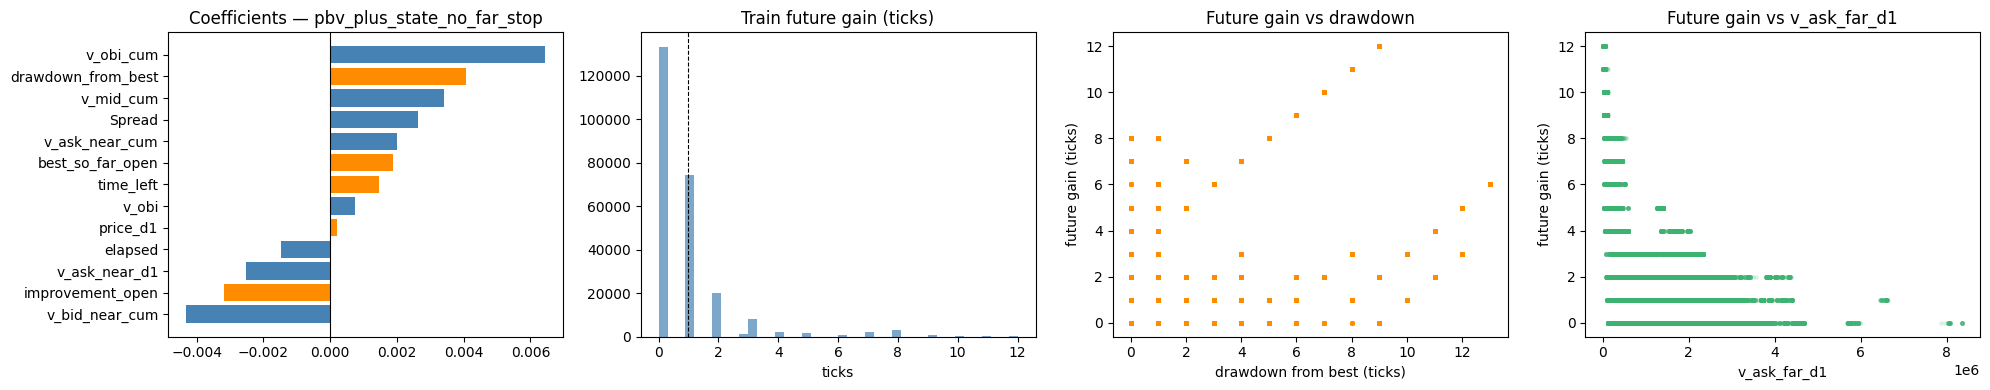

Top feature correlations with future gain:
v_ask_far_d1         -0.5064
v_ask_near_d1        -0.4088
Spread                0.3493
v_mid_cum             0.3314
drawdown_from_best    0.3115
v_obi                 0.2601
v_obi_cum             0.2398
best_so_far_open      0.2254
time_left             0.2218
elapsed              -0.2218
improvement_open     -0.2055
v_ask_near_cum       -0.1888

Correlations with v_ask_far_d1:
future_gain          -0.5064
drawdown_from_best   -0.4623
v_obi_cum            -0.0002
v_mid_cum            -0.3547

Univariate far-only model: test_rmse=0.00654 | test_corr=0.1668


In [23]:
# ============================================================
# CELL 5: Single-Stock Diagnostics + Far-Feature Checks
# ============================================================
diag_df = diag_train.copy()
feat_corr = diag_df[sorted(set(FEAT_FULL)) + ["future_gain"]].corr()["future_gain"].drop("future_gain")
feat_corr = feat_corr.sort_values(key=np.abs, ascending=False)

far_corrs = diag_df[["v_ask_far_d1", "future_gain", "drawdown_from_best", "v_obi_cum", "v_mid_cum"]].corr()["v_ask_far_d1"].drop("v_ask_far_d1")
far_uni_train = fit_regression(FEAT_FAR_ONLY, diag_train, diag_test)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].barh(coef_df["feature"], coef_df["coef"], color=["darkorange" if f in FEAT_STATE else "steelblue" for f in coef_df["feature"]])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title(f"Coefficients — {best_name}")

axes[1].hist(diag_train["future_gain"] / TICK_SIZE, bins=40, alpha=0.7, color="steelblue", edgecolor="none")
axes[1].axvline(1.0, color="black", lw=0.8, ls="--")
axes[1].set_title("Train future gain (ticks)")
axes[1].set_xlabel("ticks")

axes[2].scatter(diag_train["drawdown_from_best"] / TICK_SIZE, diag_train["future_gain"] / TICK_SIZE, s=6, alpha=0.15, color="darkorange")
axes[2].set_title("Future gain vs drawdown")
axes[2].set_xlabel("drawdown from best (ticks)")
axes[2].set_ylabel("future gain (ticks)")

axes[3].scatter(diag_train["v_ask_far_d1"], diag_train["future_gain"] / TICK_SIZE, s=6, alpha=0.12, color="mediumseagreen")
axes[3].set_title("Future gain vs v_ask_far_d1")
axes[3].set_xlabel("v_ask_far_d1")
axes[3].set_ylabel("future gain (ticks)")

plt.tight_layout()
plt.show()

print("Top feature correlations with future gain:")
print(feat_corr.head(12).to_string(float_format=lambda x: f"{x:0.4f}"))
print("\nCorrelations with v_ask_far_d1:")
print(far_corrs.to_string(float_format=lambda x: f"{x:0.4f}"))
print(f"\nUnivariate far-only model: test_rmse={far_uni_train['test_rmse']:0.5f} | test_corr={far_uni_train['test_corr']:0.4f}")

In [24]:
# ============================================================
# CELL 6: Causal Simulation Functions
# ============================================================
def summarize_results(label, res_df, threshold=np.nan, edge_hit=False):
    return {
        "Model": label,
        "Threshold": threshold,
        "Threshold edge": edge_hit,
        "Mean $": res_df["improvement"].mean(),
        "Mean ticks": res_df["improvement_ticks"].mean(),
        "Median ticks": res_df["improvement_ticks"].median(),
        "Beat %": 100 * (res_df["improvement"] > 0).mean(),
        "Fire %": 100 * res_df["fired"].mean(),
        "Exec s": res_df["exec_s"].mean(),
        "Oracle gap ticks": res_df["oracle_gap_ticks"].mean(),
    }


def simulate_stop_rule(model, scaler, feat_cols, df_features, df_raw, stop_threshold):
    df_s = df_features.copy()
    df_s["pred_future_gain"] = model.predict(scaler.transform(df_s[feat_cols].values))

    rows = []
    for minute, grp in df_s.groupby("Minute"):
        window = grp.sort_values("elapsed")
        twap_price = window["twap_true"].iloc[0]

        fired = window[window["pred_future_gain"] <= stop_threshold]
        if not fired.empty:
            exec_row = fired.iloc[0]
            fired_flag = True
        else:
            exec_row = window.iloc[-1]
            fired_flag = False

        oracle_row = window.loc[window["improvement_twap"].idxmax()]
        rows.append({
            "Minute": minute,
            "exec_s": exec_row["elapsed"],
            "fired": fired_flag,
            "improvement": exec_row["improvement_twap"],
            "improvement_ticks": exec_row["improvement_twap"] / exec_row["tick_size"],
            "pred_future_gain": exec_row["pred_future_gain"],
            "oracle_improvement": oracle_row["improvement_twap"],
            "oracle_gap_ticks": (oracle_row["improvement_twap"] - exec_row["improvement_twap"]) / exec_row["tick_size"],
        })
    return pd.DataFrame(rows)


def tune_stop_threshold(model, scaler, feat_cols, df_train_features, df_raw, tick_size):
    rows = []
    for ticks in STOP_GRID_TICKS:
        thr = ticks * tick_size
        res = simulate_stop_rule(model, scaler, feat_cols, df_train_features, df_raw, thr)
        rows.append({
            "threshold_ticks": ticks,
            "mean_ticks": res["improvement_ticks"].mean(),
            "beat_pct": 100 * (res["improvement"] > 0).mean(),
            "fire_pct": 100 * res["fired"].mean(),
            "exec_s": res["exec_s"].mean(),
            "oracle_gap_ticks": res["oracle_gap_ticks"].mean(),
        })
    tune_df = pd.DataFrame(rows)
    best_idx = tune_df.sort_values(["mean_ticks", "beat_pct", "exec_s"], ascending=[False, False, True]).index[0]
    best_ticks = float(tune_df.loc[best_idx, "threshold_ticks"])
    return best_ticks * tick_size, tune_df


def simulate_fixed_time(df_raw, minutes, target_s):
    rows = []
    df_s = df_raw[df_raw["Minute"].isin(minutes) & df_raw["eligible"]].copy()
    for minute, grp in df_s.groupby("Minute"):
        window = grp.sort_values("elapsed")
        hit = window[window["elapsed"] >= target_s]
        exec_row = hit.iloc[0] if not hit.empty else window.iloc[-1]
        oracle_row = window.loc[window["improvement_twap"].idxmax()]
        rows.append({
            "Minute": minute,
            "exec_s": exec_row["elapsed"],
            "fired": True,
            "improvement": exec_row["improvement_twap"],
            "improvement_ticks": exec_row["improvement_twap"] / exec_row["tick_size"],
            "pred_future_gain": np.nan,
            "oracle_improvement": oracle_row["improvement_twap"],
            "oracle_gap_ticks": (oracle_row["improvement_twap"] - exec_row["improvement_twap"]) / exec_row["tick_size"],
        })
    return pd.DataFrame(rows)


def simulate_trailing_stop(df_raw, minutes, giveback):
    rows = []
    df_s = df_raw[df_raw["Minute"].isin(minutes) & df_raw["eligible"]].copy()
    for minute, grp in df_s.groupby("Minute"):
        window = grp.sort_values("elapsed")
        best_price = -np.inf if SIDE == "SELL" else np.inf
        exec_row = window.iloc[-1]
        fired_flag = False

        for _, row in window.iterrows():
            px = row[EXEC_PRICE_COL]
            if SIDE == "SELL":
                best_price = max(best_price, px)
                giveback_now = best_price - px
            else:
                best_price = min(best_price, px)
                giveback_now = px - best_price

            if giveback_now >= giveback:
                exec_row = row
                fired_flag = True
                break

        oracle_row = window.loc[window["improvement_twap"].idxmax()]
        rows.append({
            "Minute": minute,
            "exec_s": exec_row["elapsed"],
            "fired": fired_flag,
            "improvement": exec_row["improvement_twap"],
            "improvement_ticks": exec_row["improvement_twap"] / exec_row["tick_size"],
            "pred_future_gain": np.nan,
            "oracle_improvement": oracle_row["improvement_twap"],
            "oracle_gap_ticks": (oracle_row["improvement_twap"] - exec_row["improvement_twap"]) / exec_row["tick_size"],
        })
    return pd.DataFrame(rows)


def tune_trailing_stop(df_raw, minutes, tick_size):
    rows = []
    for ticks in TRAILING_GRID_TICKS:
        res = simulate_trailing_stop(df_raw, minutes, ticks * tick_size)
        rows.append({
            "threshold_ticks": ticks,
            "mean_ticks": res["improvement_ticks"].mean(),
            "beat_pct": 100 * (res["improvement"] > 0).mean(),
            "fire_pct": 100 * res["fired"].mean(),
            "exec_s": res["exec_s"].mean(),
            "oracle_gap_ticks": res["oracle_gap_ticks"].mean(),
        })
    tune_df = pd.DataFrame(rows)
    best_idx = tune_df.sort_values(["mean_ticks", "beat_pct", "exec_s"], ascending=[False, False, True]).index[0]
    best_ticks = float(tune_df.loc[best_idx, "threshold_ticks"])
    return best_ticks * tick_size, tune_df

                     Model  Threshold  Threshold edge  Mean $  Mean ticks  Median ticks   Beat %    Fire %   Exec s  Oracle gap ticks
             far_only_stop    2.00000           False 0.00085     0.08489       0.00000 33.33333 100.00000  4.31683           0.41975
             pbv_only_stop    0.50000           False 0.00196     0.19600       0.00000 41.97531 100.00000  7.46862           0.30864
           pbv_no_far_stop    0.50000           False 0.00184     0.18365       0.00000 43.20988 100.00000 10.26741           0.32099
       pbv_plus_state_stop    0.50000           False 0.00159     0.15896       0.00000 40.74074 100.00000  8.18277           0.34568
pbv_plus_state_no_far_stop    0.50000           False 0.00159     0.15896       0.00000 40.74074 100.00000  8.17304           0.34568
             trailing_stop    0.50000           False 0.00085     0.08489       0.00000 37.03704  39.50617 33.61862           0.41975
                 fixed_30s        NaN           False 0.00036 

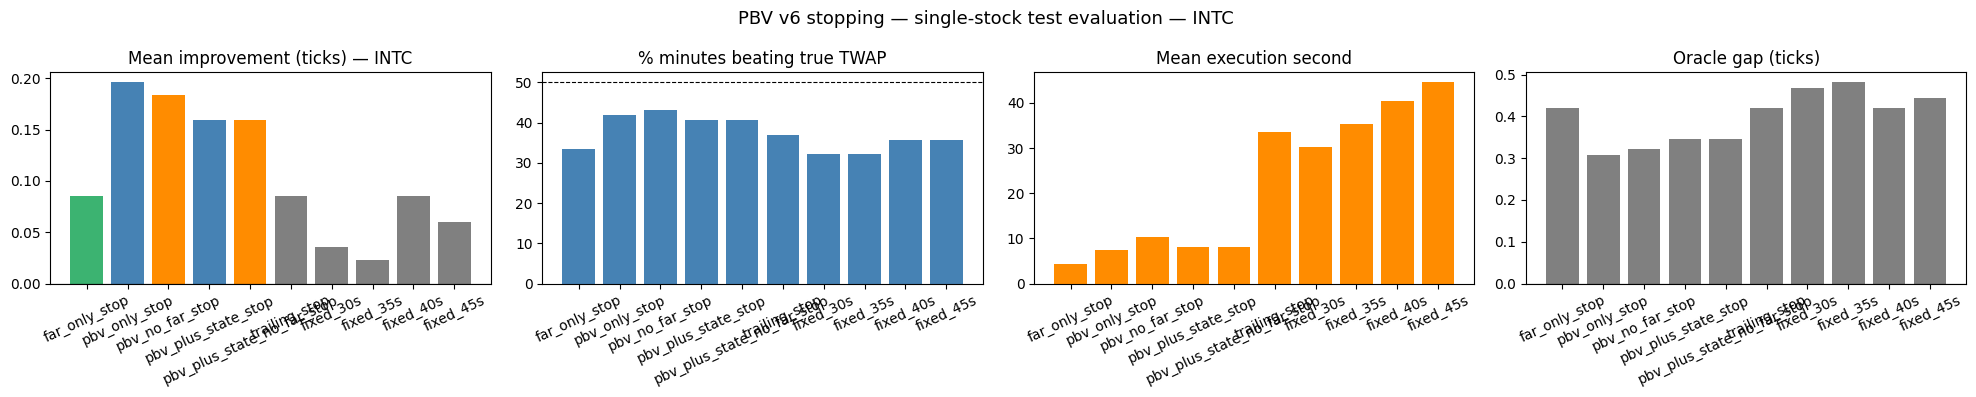


Stop-threshold search (single stock):

far_only_stop
 threshold_ticks  mean_ticks  beat_pct  fire_pct   exec_s  oracle_gap_ticks
        -1.00000     0.09328  40.21164   2.64550 43.99814           0.84127
        -0.50000     0.08799  40.21164   6.87831 43.12115           0.84656
         0.00000     0.13032  44.44444  32.27513 35.05971           0.80423
         0.50000     0.23085  47.08995  73.01587 16.68229           0.70370
         1.00000     0.19381  44.97354  85.71429  9.98601           0.74074
         1.50000     0.19381  44.44444  92.59259  6.72458           0.74074
         2.00000     0.24143  44.97354  97.35450  4.50934           0.69312
         3.00000     0.22027  44.44444 100.00000  3.26097           0.71429
         4.00000     0.22027  44.44444 100.00000  3.26097           0.71429
         5.00000     0.22027  44.44444 100.00000  3.26097           0.71429
         6.00000     0.22027  44.44444 100.00000  3.26097           0.71429
         8.00000     0.22027  44.4

In [25]:
# ============================================================
# CELL 7: Single-Stock Evaluation — Learned Stop vs Causal Baselines
# ============================================================
single_stock_rows = []
res_map = {}
tune_map = {}

for name, feats in model_specs.items():
    info = fit_results[name]
    best_thr, tune_df = tune_stop_threshold(info["model"], info["scaler"], feats, info["df_train"], train_raw, TICK_SIZE)
    res = simulate_stop_rule(info["model"], info["scaler"], feats, info["df_test"], train_raw, best_thr)
    best_ticks = best_thr / TICK_SIZE
    edge_hit = np.isclose(best_ticks, STOP_GRID_TICKS.min()) or np.isclose(best_ticks, STOP_GRID_TICKS.max())
    res_map[name] = res
    tune_map[name] = tune_df
    single_stock_rows.append(summarize_results(name, res, threshold=best_ticks, edge_hit=edge_hit))

trailing_thr, trailing_tune = tune_trailing_stop(train_raw, train_mins, TICK_SIZE)
res_trailing = simulate_trailing_stop(train_raw, test_mins, trailing_thr)
res_map["trailing_stop"] = res_trailing
single_stock_rows.append(summarize_results("trailing_stop", res_trailing, threshold=trailing_thr / TICK_SIZE, edge_hit=False))

for target_s in FIXED_TIMES:
    label = f"fixed_{int(target_s)}s"
    res = simulate_fixed_time(train_raw, test_mins, target_s)
    res_map[label] = res
    single_stock_rows.append(summarize_results(label, res, threshold=np.nan, edge_hit=False))

twap_zero = pd.DataFrame({
    "Minute": sorted(test_mins),
    "exec_s": np.nan,
    "fired": False,
    "improvement": 0.0,
    "improvement_ticks": 0.0,
    "pred_future_gain": np.nan,
    "oracle_improvement": np.nan,
    "oracle_gap_ticks": np.nan,
})
single_stock_rows.append(summarize_results("true_twap_ref", twap_zero, threshold=np.nan, edge_hit=False))

single_stock_summary = pd.DataFrame(single_stock_rows)
order = ["far_only_stop", "pbv_only_stop", "pbv_no_far_stop", "pbv_plus_state_stop", "pbv_plus_state_no_far_stop", "trailing_stop", "fixed_30s", "fixed_35s", "fixed_40s", "fixed_45s", "true_twap_ref"]
single_stock_summary["rank"] = single_stock_summary["Model"].map({m: i for i, m in enumerate(order)})
single_stock_summary = single_stock_summary.sort_values(["rank", "Mean ticks"], ascending=[True, False]).drop(columns="rank")
print(single_stock_summary.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
plot_df = single_stock_summary[single_stock_summary["Model"].isin(order[:-1])]
labels = plot_df["Model"]

axes[0].bar(labels, plot_df["Mean ticks"], color=["gray" if "fixed" in m or "trailing" in m else ("darkorange" if "no_far" in m else ("mediumseagreen" if "far_only" in m else "steelblue")) for m in labels])
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Mean improvement (ticks) — {STOCK}")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(labels, plot_df["Beat %"], color="steelblue")
axes[1].axhline(50, color="black", lw=0.8, ls="--")
axes[1].set_title("% minutes beating true TWAP")
axes[1].tick_params(axis="x", rotation=25)

axes[2].bar(labels, plot_df["Exec s"], color="darkorange")
axes[2].set_title("Mean execution second")
axes[2].tick_params(axis="x", rotation=25)

axes[3].bar(labels, plot_df["Oracle gap ticks"], color="gray")
axes[3].axhline(0, color="black", lw=0.8)
axes[3].set_title("Oracle gap (ticks)")
axes[3].tick_params(axis="x", rotation=25)

plt.suptitle(f"PBV v6 stopping — single-stock test evaluation — {STOCK}", fontsize=13)
plt.tight_layout()
plt.show()

print("\nStop-threshold search (single stock):")
for name, tune_df in tune_map.items():
    print(f"\n{name}")
    print(tune_df.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

print("\nSingle-stock far-feature deltas (no_far minus parent):")
single_delta_df = pd.DataFrame([
    {
        "comparison": "pbv_no_far - pbv_only",
        "delta_mean_ticks": single_stock_summary.set_index("Model").loc["pbv_no_far_stop", "Mean ticks"] - single_stock_summary.set_index("Model").loc["pbv_only_stop", "Mean ticks"],
        "delta_exec_s": single_stock_summary.set_index("Model").loc["pbv_no_far_stop", "Exec s"] - single_stock_summary.set_index("Model").loc["pbv_only_stop", "Exec s"],
    },
    {
        "comparison": "pbv_plus_state_no_far - pbv_plus_state",
        "delta_mean_ticks": single_stock_summary.set_index("Model").loc["pbv_plus_state_no_far_stop", "Mean ticks"] - single_stock_summary.set_index("Model").loc["pbv_plus_state_stop", "Mean ticks"],
        "delta_exec_s": single_stock_summary.set_index("Model").loc["pbv_plus_state_no_far_stop", "Exec s"] - single_stock_summary.set_index("Model").loc["pbv_plus_state_stop", "Exec s"],
    },
])
print(single_delta_df.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

print("\nTrailing-stop tuning (single stock):")
print(trailing_tune.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

In [26]:
# ============================================================
# CELL 8: Cross-Stock Evaluation
# ============================================================
def run_stock(stock):
    d = load_and_compute(stock)
    tick_size = float(d["tick_size"].iloc[0])
    train_mins_s, test_mins_s = split_minutes(d)

    out = {}
    for name, feats in model_specs.items():
        _, df_tr, df_te = build_dataset(d, feats, train_mins_s, test_mins_s)
        info = fit_regression(feats, df_tr, df_te)
        thr, tune_df = tune_stop_threshold(info["model"], info["scaler"], feats, info["df_train"], d, tick_size)
        res = simulate_stop_rule(info["model"], info["scaler"], feats, info["df_test"], d, thr)
        best_ticks = thr / tick_size
        edge_hit = np.isclose(best_ticks, STOP_GRID_TICKS.min()) or np.isclose(best_ticks, STOP_GRID_TICKS.max())
        out[name] = summarize_results(name, res, threshold=best_ticks, edge_hit=edge_hit)
        out[name]["Test Corr"] = info["test_corr"]
        out[name]["Test RMSE"] = info["test_rmse"]
        out[name]["Train Mean ticks"] = tune_df["mean_ticks"].max()

    trailing_thr, _ = tune_trailing_stop(d, train_mins_s, tick_size)
    out["trailing_stop"] = summarize_results("trailing_stop", simulate_trailing_stop(d, test_mins_s, trailing_thr), threshold=trailing_thr / tick_size, edge_hit=False)
    out["trailing_stop"]["Test Corr"] = np.nan
    out["trailing_stop"]["Test RMSE"] = np.nan
    out["trailing_stop"]["Train Mean ticks"] = np.nan

    for target_s in FIXED_TIMES:
        label = f"fixed_{int(target_s)}s"
        out[label] = summarize_results(label, simulate_fixed_time(d, test_mins_s, target_s), threshold=np.nan, edge_hit=False)
        out[label]["Test Corr"] = np.nan
        out[label]["Test RMSE"] = np.nan
        out[label]["Train Mean ticks"] = np.nan

    out["true_twap_ref"] = {
        "Model": "true_twap_ref",
        "Threshold": np.nan,
        "Threshold edge": False,
        "Mean $": 0.0,
        "Mean ticks": 0.0,
        "Median ticks": 0.0,
        "Beat %": 0.0,
        "Fire %": 0.0,
        "Exec s": np.nan,
        "Oracle gap ticks": np.nan,
        "Test Corr": np.nan,
        "Test RMSE": np.nan,
        "Train Mean ticks": np.nan,
    }
    return out


print("Running cross-stock PBV v6 stopping pipeline...")
xs = {s: run_stock(s) for s in STOCKS_ALL}
print("Done.")

rows = []
eval_order = ["far_only_stop", "pbv_only_stop", "pbv_no_far_stop", "pbv_plus_state_stop", "pbv_plus_state_no_far_stop", "trailing_stop", "fixed_30s", "fixed_35s", "fixed_40s", "fixed_45s", "true_twap_ref"]
for stock in STOCKS_ALL:
    for model_name in eval_order:
        rows.append({
            "Stock": stock,
            "Model": model_name,
            **xs[stock][model_name],
        })

xs_df = pd.DataFrame(rows)
print(xs_df[["Stock", "Model", "Threshold", "Threshold edge", "Mean ticks", "Beat %", "Exec s", "Oracle gap ticks", "Test Corr", "Test RMSE"]].to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

print("\nCross-stock average by model:")
print(xs_df.groupby("Model")[["Mean ticks", "Beat %", "Exec s", "Oracle gap ticks", "Test Corr", "Test RMSE"]].mean(numeric_only=True).sort_values("Mean ticks", ascending=False).to_string(float_format=lambda x: f"{x:0.5f}"))

print("\nCross-stock far-feature deltas (no_far minus parent):")
delta_rows = []
for stock in STOCKS_ALL:
    stock_df = xs_df[xs_df["Stock"] == stock].set_index("Model")
    delta_rows.append({
        "Stock": stock,
        "pbv_delta_mean_ticks": stock_df.loc["pbv_no_far_stop", "Mean ticks"] - stock_df.loc["pbv_only_stop", "Mean ticks"],
        "pbv_plus_state_delta_mean_ticks": stock_df.loc["pbv_plus_state_no_far_stop", "Mean ticks"] - stock_df.loc["pbv_plus_state_stop", "Mean ticks"],
        "pbv_delta_test_rmse": stock_df.loc["pbv_no_far_stop", "Test RMSE"] - stock_df.loc["pbv_only_stop", "Test RMSE"],
        "pbv_plus_state_delta_test_rmse": stock_df.loc["pbv_plus_state_no_far_stop", "Test RMSE"] - stock_df.loc["pbv_plus_state_stop", "Test RMSE"],
    })
delta_df = pd.DataFrame(delta_rows)
print(delta_df.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

Running cross-stock PBV v6 stopping pipeline...
Done.
Stock                      Model  Threshold  Threshold edge  Mean ticks   Beat %   Exec s  Oracle gap ticks  Test Corr  Test RMSE
 AMZN              far_only_stop    8.00000           False     0.75445 58.02469  7.05095           6.24691    0.01453    0.06534
 AMZN              pbv_only_stop    3.00000           False     1.02606 53.08642 25.24054           5.97531    0.40752    0.05987
 AMZN            pbv_no_far_stop    3.00000           False     1.08779 60.49383 25.59074           5.91358    0.39915    0.06033
 AMZN        pbv_plus_state_stop    5.00000           False     1.02606 59.25926 17.10438           5.97531    0.41427    0.05992
 AMZN pbv_plus_state_no_far_stop    3.00000           False     1.26063 60.49383 23.66390           5.74074    0.40628    0.06041
 AMZN              trailing_stop    0.50000           False     0.35939 54.32099 16.07937           6.64198        NaN        NaN
 AMZN                  fixed_30s    

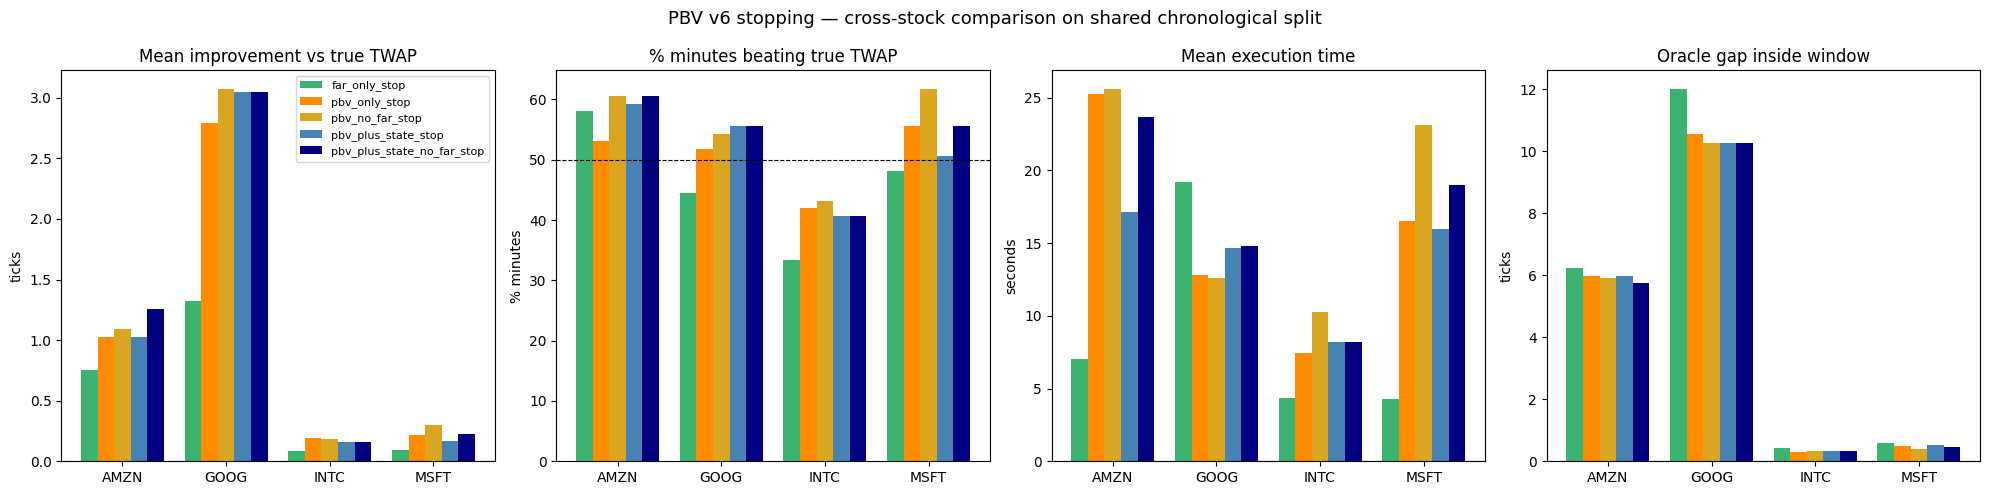

In [27]:
# ============================================================
# CELL 9: Cross-Stock Visual Summary
# ============================================================
plot_models = ["far_only_stop", "pbv_only_stop", "pbv_no_far_stop", "pbv_plus_state_stop", "pbv_plus_state_no_far_stop"]
plot_colors = {
    "far_only_stop": "mediumseagreen",
    "pbv_only_stop": "darkorange",
    "pbv_no_far_stop": "goldenrod",
    "pbv_plus_state_stop": "steelblue",
    "pbv_plus_state_no_far_stop": "navy",
}

x = np.arange(len(STOCKS_ALL))
width = 0.16
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for j, (metric, ylabel, title) in enumerate([
    ("Mean ticks", "ticks", "Mean improvement vs true TWAP"),
    ("Beat %", "% minutes", "% minutes beating true TWAP"),
    ("Exec s", "seconds", "Mean execution time"),
    ("Oracle gap ticks", "ticks", "Oracle gap inside window"),
]):
    ax = axes[j]
    for i, model_name in enumerate(plot_models):
        vals = [xs[s][model_name][metric] for s in STOCKS_ALL]
        ax.bar(x + (i - 2) * width, vals, width, label=model_name, color=plot_colors[model_name])
    ax.axhline(50 if metric == "Beat %" else 0, color="black", lw=0.8, ls="--")
    ax.set_xticks(x)
    ax.set_xticklabels(STOCKS_ALL)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].legend(fontsize=8)
plt.suptitle("PBV v6 stopping — cross-stock comparison on shared chronological split", fontsize=13)
plt.tight_layout()
plt.show()

## Notes

- The target is **future gain from waiting** over the remaining eligible window, which matches the stopping problem more directly than a pointwise classification label.
- Evaluation is against **true in-window TWAP**, so a positive score means the rule beat the benchmark that would actually matter here.
- This version adds explicit **far-feature ablations** so the importance of `v_ask_far_d1` is tested by performance deltas, not inferred from one shrunk coefficient.
- `Threshold edge = True` means the tuned stop level hit the search boundary, so that model may still want a wider threshold grid. The grid is extended to `15` ticks here to reduce the remaining GOOG boundary risk.
- The fixed-time and trailing-stop rules are included to check whether a simple timing heuristic already captures most of the available improvement.